# Chapter 18: Reinforcement Learning (RL)

Bab ini membahas paradigma pembelajaran di mana sebuah agen belajar berinteraksi dengan lingkungan untuk memaksimalkan imbalan (*reward*) kumulatif melalui serangkaian aksi.

---

## 18.1 Mengoptimasi Hadiah (Reward)
Dalam *Reinforcement Learning*, sebuah agen *software* melakukan observasi terhadap lingkungan dan mengambil aksi.
* **Reward vs Penalty**: Setiap aksi dapat menghasilkan hadiah positif (imbalan) atau negatif (hukuman).
* **Tujuan**: Mempelajari strategi (policy) paling efektif untuk memaksimalkan total hadiah jangka panjang.

---

## 18.2 Policy Search & OpenAI Gym
* **Policy**: Algoritma atau "otak" yang digunakan agen untuk menentukan aksi.
* **Stochastic Policy**: Kebijakan yang memberikan probabilitas untuk setiap aksi (acak terkontrol).
* **OpenAI Gym**: Karena melatih agen di dunia nyata sangat berisiko dan mahal, kita menggunakan toolkit simulasi seperti OpenAI Gym (atau Gymnasium) untuk menyediakan lingkungan (*environment*) latihan.

---

## 18.3 Neural Network Policies
Neural Network dapat digunakan sebagai *policy*.
* **Input**: Observasi lingkungan.
* **Output**: Probabilitas untuk setiap aksi.
* **Eksplorasi**: Agen memilih aksi berdasarkan probabilitas tersebut untuk menjaga keseimbangan antara mengeksplorasi hal baru dan mengeksploitasi pengetahuan yang sudah ada.

---

## 18.4 Credit Assignment Problem & Discount Factor
Masalah utama RL adalah menentukan aksi mana yang bertanggung jawab atas hadiah yang diterima (mungkin aksi 10 langkah lalu yang baru membuahkan hasil sekarang).
* **Discount Factor ($\gamma$)**: Strategi untuk mengevaluasi aksi dengan menjumlahkan semua hadiah di masa depan, namun memberikan bobot yang lebih kecil untuk hadiah yang jauh di depan. Nilai akumulasi ini disebut **Return**.

---

## 18.5 Markov Decision Processes (MDP)
* **Markov Chain**: Proses stokastik di mana probabilitas menuju *state* berikutnya hanya bergantung pada *state* saat ini (tanpa memori masa lalu).
* **Bellman Optimality Equation**: Persamaan matematika yang digunakan untuk mengestimasi nilai optimal dari suatu *state* atau pasangan *state-action*.

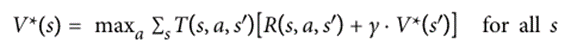

---

## 18.6 Q-Learning & Exploration Policies
* **Q-Learning**: Adaptasi algoritma yang mempelajari nilai kualitas ($Q-Value$) dari mengambil aksi tertentu di *state* tertentu tanpa mengetahui probabilitas transisi lingkungan sebelumnya.
* **$\epsilon$-greedy Policy**: Agen mengambil aksi terbaik menurut model dengan probabilitas $1-\epsilon$, dan mengambil aksi acak dengan probabilitas $\epsilon$. Ini memastikan agen tetap menjelajahi seluruh area *state*.

---

## 18.7 Deep Q-Learning (DQN)
DQN menggunakan Deep Neural Network untuk mengestimasi $Q-Value$ pada skala besar yang tidak bisa ditangani oleh tabel Q standar.
* **Experience Replay**: Menyimpan pengalaman agen dalam *buffer* dan mengambil sampel acak untuk melatih model guna memutus korelasi antar data sekuensial.
* **Fixed Q-Value Targets**: Menggunakan dua jaringan; **Online Model** yang terus belajar, dan **Target Model** yang diperbarui secara berkala untuk menjaga stabilitas target prediksi.

---

## 18.8 Variasi DQN Tingkat Lanjut
* **Double DQN**: Mengatasi masalah estimasi berlebih (*overestimation*) pada Q-Value dengan memisahkan pemilihan aksi dari evaluasi aksi.
* **Dueling DQN**: Memisahkan nilai *state* ($V$) dan keuntungan aksi (*Advantage*), yang membantu model memahami bahwa beberapa *state* sangat berharga tidak peduli aksi apa yang diambil.
* **Prioritized Experience Replay**: Memberikan bobot lebih tinggi pada pengalaman yang memiliki kesalahan prediksi (*loss*) besar agar model belajar lebih sering dari peristiwa penting.



---

## 18.9 TF-Agents Library
Library khusus dari TensorFlow untuk RL yang menyediakan komponen siap pakai:
* **Wrappers**: Seperti `ActionClipWrapper` (membatasi aksi) atau `TimeLimit`.
* **Preprocessing**: Mendukung *grayscale*, *downsampling*, dan *frame skipping* untuk mempercepat pelatihan.
* **Arsitektur Paralel**: Memisahkan **Driver** (yang mengumpulkan data dari lingkungan) dan **Observers/Learners** (yang melatih model dari *replay buffer*).

---

## 18.10 Membuat Collect Driver
Driver bertugas mengelola interaksi antara *policy* dan lingkungan.
1. Driver mengambil *state* dari lingkungan.
2. Memilih aksi berdasarkan *policy*.
3. Mengirim aksi ke lingkungan dan menerima *state* berikutnya serta *reward*.
4. Membuat objek **Trajectory** (transisi data) untuk disimpan ke dalam *replay buffer*.